# Resume Screening System ML

In [32]:
import pandas as pd

df = pd.read_csv('/content/resume_screening_dataset.csv')

print("Shape:", df.shape)

df.head()

Shape: (50000, 24)


,candidate_id,age,gender,degree,specialization,university_tier,cgpa,years_experience,internships_count,projects_count,...,deep_learning_skill,communication_skill,leadership_skill,github_projects,kaggle_activity_score,hackathons_participated,expected_salary_lpa,location,employment_gap_months,selected
0,CAND-000001,24,Female,B.Tech,Information Technology,Tier 3,8.75,6,1,2,...,7,6,4,3,6.1,2,16.5,Kolkata,0,No
1,CAND-000002,37,Male,B.E.,Mechanical,Tier 2,7.08,14,1,5,...,4,10,8,3,8.2,1,27.6,Delhi,3,No
2,CAND-000003,32,Female,Ph.D,Information Technology,Tier 1,7.08,10,0,6,...,7,6,4,5,6.0,2,22.1,Delhi,0,Yes
3,CAND-000004,28,Male,B.E.,Data Science,Tier 3,8.28,10,1,3,...,4,6,4,5,9.7,2,19.4,Pune,0,Yes
4,CAND-000005,25,Female,B.E.,Business Analytics,Tier 1,7.42,4,0,1,...,4,6,4,2,2.8,1,14.3,Mumbai,0,No


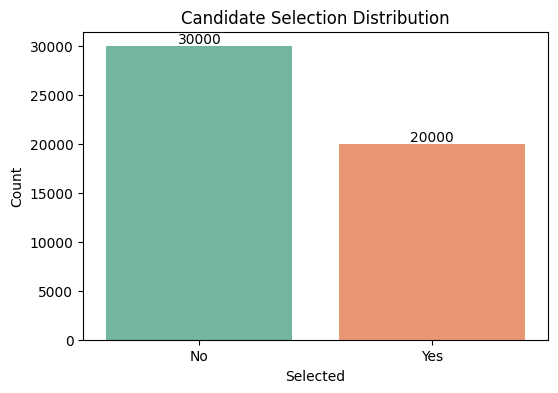

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
ax = sns.countplot(x='selected', data=df, hue='selected', palette='Set2', legend=False)
plt.title('Candidate Selection Distribution')
plt.xlabel('Selected')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
plt.show()

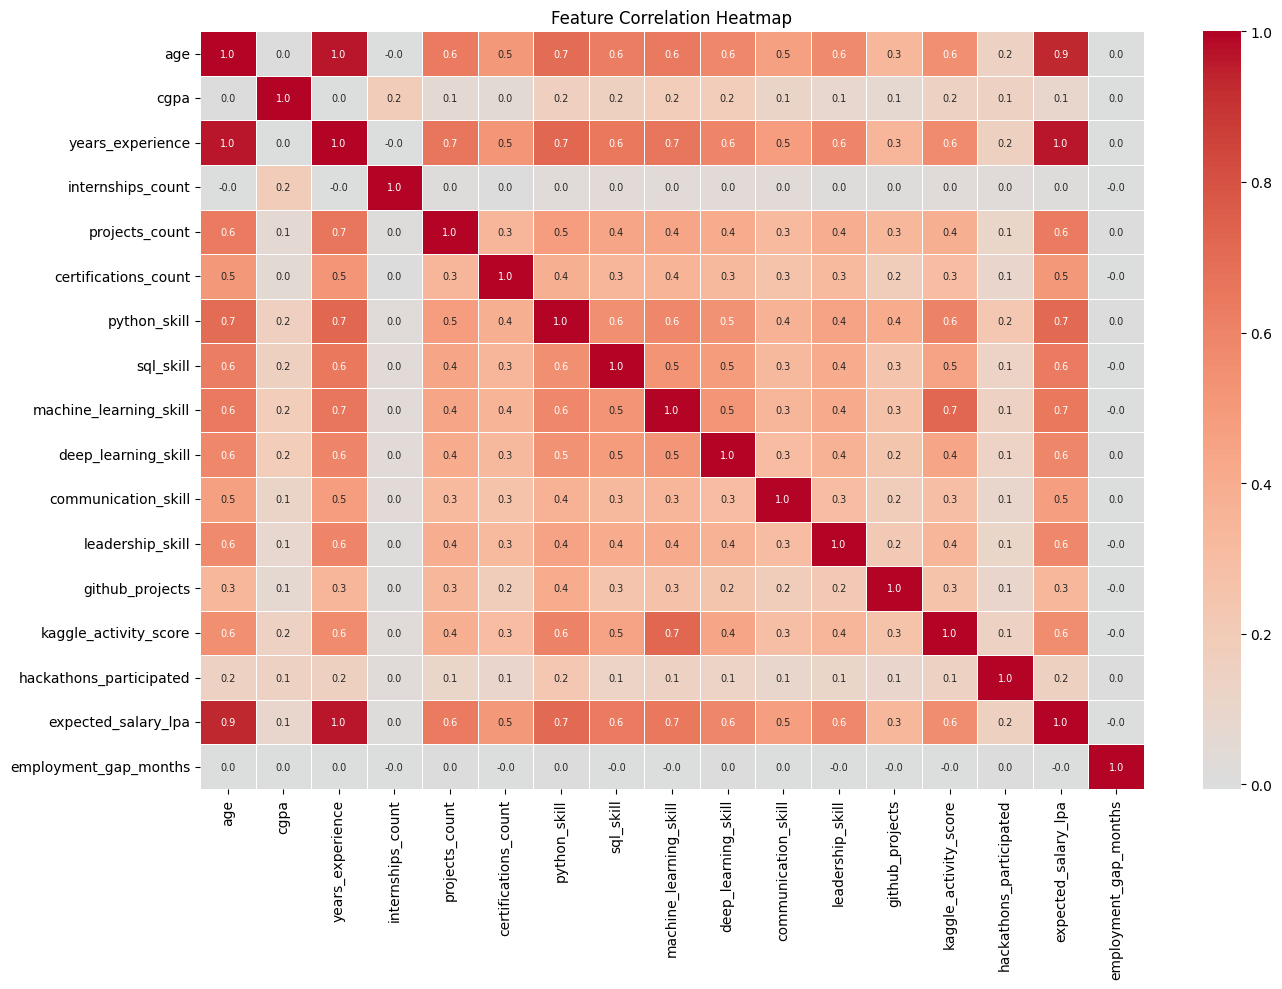

In [34]:
plt.figure(figsize=(14, 10))
corr_matrix = df.select_dtypes(include='number').corr()
sns.heatmap(corr_matrix, annot=True, fmt='.1f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={"size": 7})
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [35]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Data Preprocessing
# Remove irrelevant columns
columns_to_drop = []
if 'Unnamed: 0' in df.columns:
    columns_to_drop.append('Unnamed: 0')

if columns_to_drop:
    df = df.drop(columns=columns_to_drop)

# Handle missing values based on actual missing data
missing_counts = df.isnull().sum()
columns_with_missing_data = missing_counts[missing_counts > 0].index.tolist()

if columns_with_missing_data:
    print("Columns with missing values:")
    print(columns_with_missing_data)

In [36]:
# Target variable definition and encoding
target_column = 'selected'
y = df[target_column]

# Encode target variable if required (e.g., 'Yes'/'No' to 0/1)
if y.dtype == 'object' or pd.api.types.is_categorical_dtype(y):
    le = LabelEncoder()
    y = le.fit_transform(y)

# Feature selection (X)
features_to_exclude = [target_column]
for col in ['Resume', 'resume', 'candidate_id', 'Candidate_ID']:
    if col in df.columns:
        features_to_exclude.append(col)

X = df.drop(columns=features_to_exclude)

# Identify categorical features in X for One-Hot Encoding
categorical_features_for_ohe = X.select_dtypes(include=['object', 'category']).columns.tolist()

if categorical_features_for_ohe:
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features_for_ohe)
        ],
        remainder='passthrough' # Keep numerical columns as they are
    )
    X = preprocessor.fit_transform(X)

In [37]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Print final dataset shapes
display(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(40000, 65)

(10000, 65)

(40000,)

(10000,)

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# 1. Logistic Regression
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model.fit(X_train, y_train)

y_pred_log_reg = log_reg_model.predict(X_test)
print("Logistic Regression Classification Report:")
print(classification_report(
    y_test,
    y_pred_log_reg,
    zero_division=0
))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91      6000
           1       0.87      0.86      0.86      4000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [39]:
from sklearn.ensemble import RandomForestClassifier

# 2. Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.90      0.89      6000
           1       0.84      0.83      0.83      4000

    accuracy                           0.87     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.87      0.87      0.87     10000



,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8926,0.870380,0.8595,0.864906
1,Random Forest,0.8693,0.844285,0.8255,0.834787


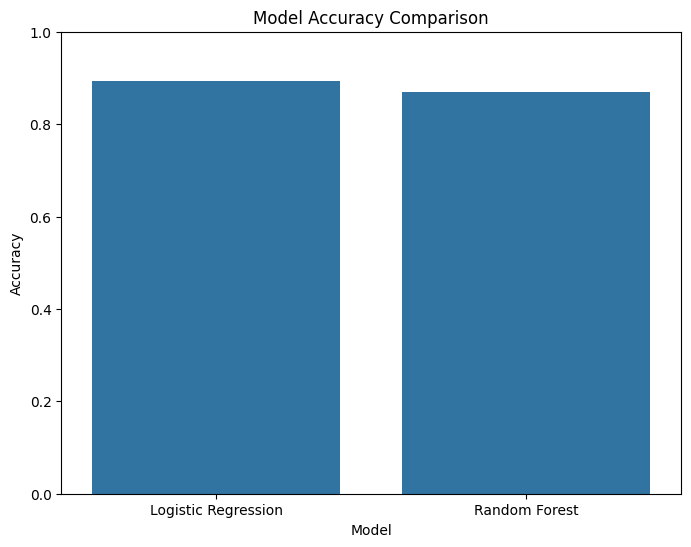

The best model based on accuracy is: Logistic Regression


In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate metrics for Logistic Regression
accuracy_lr = accuracy_score(y_test, y_pred_log_reg)
precision_lr = precision_score(y_test, y_pred_log_reg, zero_division=0)
recall_lr = recall_score(y_test, y_pred_log_reg, zero_division=0)
f1_lr = f1_score(y_test, y_pred_log_reg, zero_division=0)

# Calculate metrics for Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, zero_division=0)

# Create a comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy_lr, accuracy_rf],
    'Precision': [precision_lr, precision_rf],
    'Recall': [recall_lr, recall_rf],
    'F1 Score': [f1_lr, f1_rf]
})

display(comparison_df)

# Create a bar chart comparing model accuracies
plt.figure(figsize=(8, 6))
sns.barplot(x='Model', y='Accuracy', data=comparison_df)
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.show()

# Select the best model automatically
best_model_name = comparison_df.loc[comparison_df['Accuracy'].idxmax(), 'Model']
if best_model_name == 'Logistic Regression':
    best_model = log_reg_model
else:
    best_model = rf_model

print(f"The best model based on accuracy is: {best_model_name}")

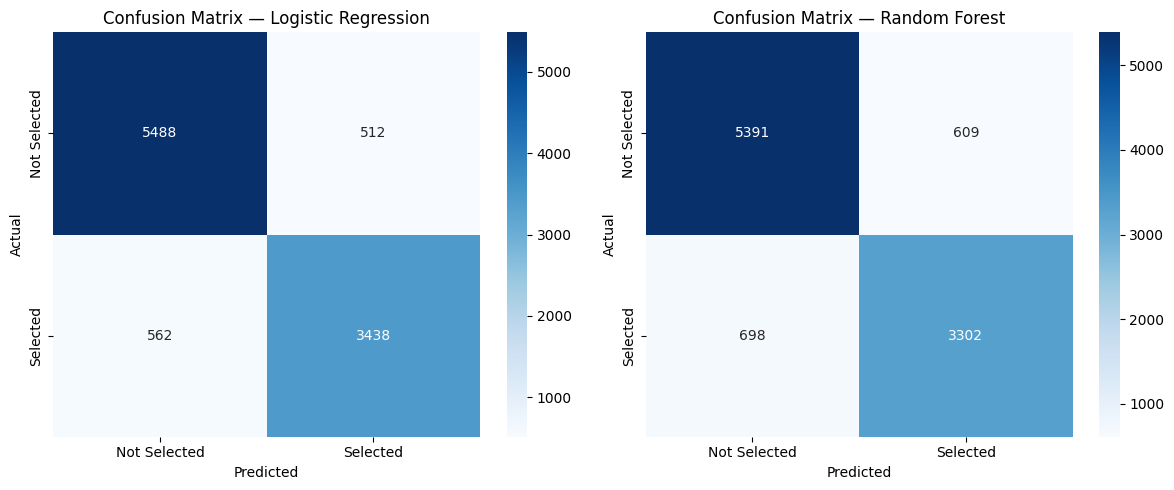

In [41]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(axes,
                              [y_pred_log_reg, y_pred_rf],
                              ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Selected', 'Selected'],
                yticklabels=['Not Selected', 'Selected'])
    ax.set_title(f'Confusion Matrix — {title}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [42]:
from sklearn.model_selection import cross_val_score

for model, name in [(log_reg_model, 'Logistic Regression'),
                    (rf_model, 'Random Forest')]:
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    print(f"{name}: {scores.mean():.4f} ± {scores.std():.4f}  "
          f"(scores: {[round(s, 3) for s in scores]})")

Logistic Regression: 0.8881 ± 0.0019  (scores: [np.float64(0.888), np.float64(0.886), np.float64(0.887), np.float64(0.892), np.float64(0.888)])
Random Forest: 0.8694 ± 0.0023  (scores: [np.float64(0.868), np.float64(0.868), np.float64(0.873), np.float64(0.868), np.float64(0.871)])


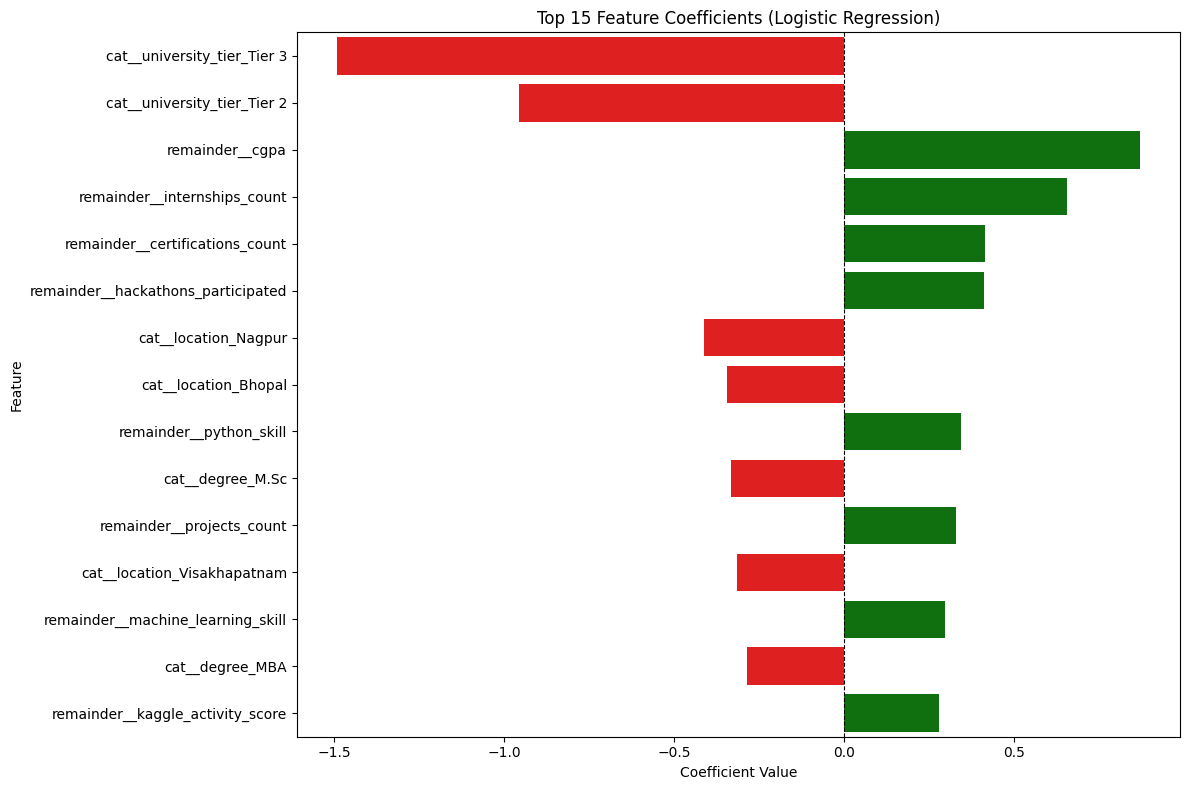

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Feature Importance / Coefficients
if best_model_name == 'Random Forest':
    feature_importances = best_model.feature_importances_
    feature_names = preprocessor.get_feature_names_out()

    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': feature_importances
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15))
    plt.title('Top 15 Feature Importances (Random Forest)')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

else:
    # Logistic Regression — Top 15 features by coefficient magnitude
    feature_names = preprocessor.get_feature_names_out()
    coefficients = best_model.coef_[0]

    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coefficients
    })
    coef_df['Abs_Coefficient'] = np.abs(coef_df['Coefficient'])
    coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False).head(15)

    plt.figure(figsize=(12, 8))
    colors = ['green' if c > 0 else 'red' for c in coef_df['Coefficient']]
    sns.barplot(x='Coefficient', y='Feature', data=coef_df, hue='Feature', palette=dict(zip(coef_df['Feature'], colors)), legend=False)
    plt.title('Top 15 Feature Coefficients (Logistic Regression)')
    plt.xlabel('Coefficient Value')
    plt.ylabel('Feature')
    plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
    plt.tight_layout()
    plt.show()

In [44]:
def predict_candidate(candidate_details):

    input_df = pd.DataFrame([candidate_details])

    feature_cols = [
        col for col in df.columns
        if col not in ['selected', 'candidate_id']
    ]

    input_df = input_df[feature_cols]

    processed_input = preprocessor.transform(input_df)

    prediction = best_model.predict(processed_input)

    return le.inverse_transform(prediction)[0]

In [45]:
import joblib

joblib.dump(best_model, "resume_screening_model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")
joblib.dump(le, "label_encoder.pkl")

print("Model files saved successfully.")

Model files saved successfully.


In [46]:
sample_candidate = {
    'age': 25,
    'gender': 'Male',
    'degree': 'B.Tech',
    'specialization': 'Computer Science',
    'university_tier': 'Tier 1',
    'cgpa': 8.5,
    'years_experience': 3,
    'internships_count': 1,
    'projects_count': 3,
    'certifications_count': 2,
    'python_skill': 8,
    'sql_skill': 7,
    'machine_learning_skill': 6,
    'deep_learning_skill': 5,
    'communication_skill': 7,
    'leadership_skill': 6,
    'github_projects': 4,
    'kaggle_activity_score': 7,
    'hackathons_participated': 2,
    'expected_salary_lpa': 15,
    'location': 'Bangalore',
    'employment_gap_months': 0
}

print(
    "Prediction:",
    predict_candidate(sample_candidate)
)

Prediction: Yes


In [47]:
import ipywidgets as widgets
from IPython.display import display

style = {'description_width': '160px'}
layout = widgets.Layout(width='400px')

cgpa       = widgets.FloatSlider(value=8.5, min=0, max=10, step=0.1, description='CGPA', style=style, layout=layout)
experience = widgets.IntSlider(value=2, min=0, max=15, description='Years Experience', style=style, layout=layout)
python_sk  = widgets.IntSlider(value=7, min=0, max=10, description='Python Skill', style=style, layout=layout)
ml_sk      = widgets.IntSlider(value=6, min=0, max=10, description='ML Skill', style=style, layout=layout)
gender     = widgets.Dropdown(options=['Male', 'Female'], description='Gender', style=style, layout=layout)
degree     = widgets.Dropdown(options=['B.Tech', 'M.Tech', 'MBA', 'BCA', 'MCA'], description='Degree', style=style, layout=layout)
location   = widgets.Dropdown(options=['Bangalore', 'Mumbai', 'Delhi', 'Hyderabad', 'Chennai'], description='Location', style=style, layout=layout)
result_out = widgets.Output()

def on_predict(b):
    candidate = {
        'age': 24, 'gender': gender.value, 'degree': degree.value,
        'specialization': 'Computer Science', 'university_tier': 'Tier 1',
        'cgpa': cgpa.value, 'years_experience': experience.value,
        'internships_count': 1, 'projects_count': 3,
        'certifications_count': 2, 'python_skill': python_sk.value,
        'sql_skill': 7, 'machine_learning_skill': ml_sk.value,
        'deep_learning_skill': 5, 'communication_skill': 7,
        'leadership_skill': 6, 'github_projects': 4,
        'kaggle_activity_score': 7, 'hackathons_participated': 2,
        'expected_salary_lpa': 12, 'location': location.value,
        'employment_gap_months': 0
    }
    result = predict_candidate(candidate)
    result_out.clear_output()
    with result_out:
        color = 'green' if result == 'Yes' else 'red'
        print(f"\nPrediction: ", end='')
        display(widgets.HTML(f"<b style='color:{color}; font-size:18px'>{result}</b>"))

btn = widgets.Button(description='Predict', button_style='primary')
btn.on_click(on_predict)

display(widgets.VBox([cgpa, experience, python_sk, ml_sk, gender, degree, location, btn, result_out]))